# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

Text(0, 0.5, 'Log(MBH)')

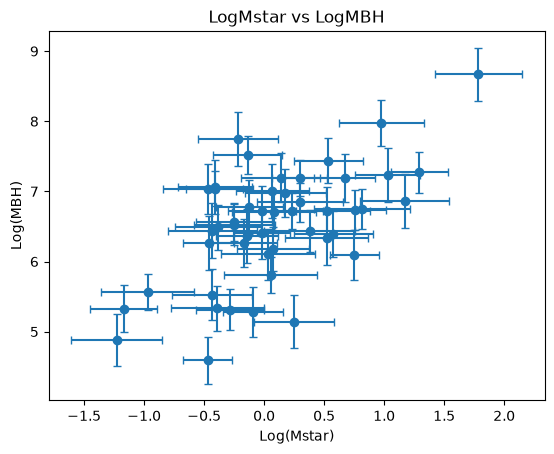

In [1]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

lMs, lMs_err, lMBH, lMBH_err = np.genfromtxt(f'acm18.csv', delimiter=',', names=True, skip_header=1,unpack = True)


plt.errorbar(lMs - 9.5, lMBH, yerr=lMBH_err, xerr = lMs_err, fmt='o', capsize=3, label='data')


plt.title('LogMstar vs LogMBH');plt.xlabel('Log(Mstar)');plt.ylabel('Log(MBH)')

OLS Fitted Parameters:
Alpha_hat = 0.80 ± 0.158
Beta_hat = 6.45 ± 0.097


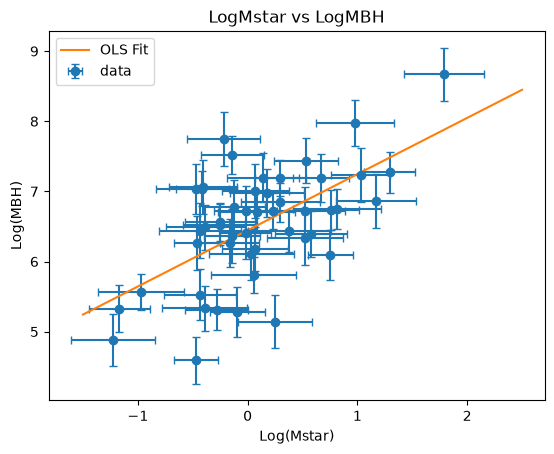

In [2]:
def ols(A, y):
    AtA_inv = np.linalg.inv(A.T @ A)
    theta = AtA_inv @ A.T @ y
    resid = y - A @ theta
    s2 = resid @ resid / (len(y) - A.shape[1])
    return theta, s2 * AtA_inv, resid

ones = np.ones_like(lMs)
A = np.column_stack((ones, lMs-9.5))

theta, cov, res = ols(A, lMBH)
beta_hat, alpha_hat = theta
sig_beta, sig_alpha = np.sqrt(np.diag(cov))

xx = np.linspace(8,12,500)

plt.errorbar(lMs-9.5, lMBH, yerr=lMBH_err, xerr = lMs_err, fmt='o', capsize=3, label='data')
plt.plot(xx-9.5, beta_hat + alpha_hat*(xx-9.5), label = 'OLS Fit')

plt.title('LogMstar vs LogMBH');plt.xlabel('Log(Mstar)');plt.ylabel('Log(MBH)');plt.legend()

print(f"OLS Fitted Parameters:\nAlpha_hat = {alpha_hat:.2f} ± {sig_alpha:.3f}\nBeta_hat = {beta_hat:.2f} ± {sig_beta:.3f}")

**ANSWER (a few sentences):**

OLS Parameter: $\hat\alpha\ = 0.80 \pm 0.158$
The specific assumptions for ols that my data violates is that the x values are absolute. OLS assumes that the x values are absolute with no error, this is not true for this specific data. By not taking the error in the x into account, this bias will lead the reported value to be shallower than the truth. How large this bias is will be related to the magnitude of $\sigma_x$. Larger error will lead to a flatter fitted trend.

OLS also assumes a constant y-uncertainty but this is also untrue for my data and should be included when fitting a model. While this error has a much smaller effect it still biases my model and should be corrected.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

WLS Fitted Parameters:
Alpha_hat = 0.78 ± 0.079
Beta_hat = 6.46 ± 0.047


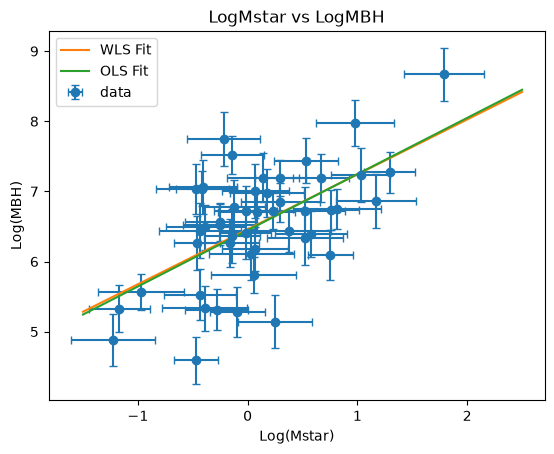

In [3]:
# Part 2: your work here
'''Weighted least squares'''
def wls(A, y, sigma):
    W = 1.0 / sigma**2
    AtWA_inv = np.linalg.inv(A.T @ (A * W[:, None]))
    theta = AtWA_inv @ A.T @ (W * y)
    return theta, AtWA_inv

w_theta, w_cov = wls(A, lMBH, lMBH_err)
  
w_beta_hat, w_alpha_hat = w_theta
w_sig_beta, w_sig_alpha = np.sqrt(np.diag(w_cov))

plt.errorbar(lMs-9.5, lMBH, yerr=lMBH_err, xerr = lMs_err, fmt='o', capsize=3, label='data')
plt.plot(xx-9.5, w_beta_hat + w_alpha_hat*(xx-9.5),label = 'WLS Fit')
plt.plot(xx-9.5, beta_hat + alpha_hat*(xx-9.5), label = 'OLS Fit')

plt.title('LogMstar vs LogMBH');plt.xlabel('Log(Mstar)');plt.ylabel('Log(MBH)');plt.legend()


print(f"WLS Fitted Parameters:\nAlpha_hat = {w_alpha_hat:.2f} ± {w_sig_alpha:.3f}\nBeta_hat = {w_beta_hat:.2f} ± {w_sig_beta:.3f}")

#### Weighted Least Squares

WLS is a strategy to upgrade OLS to take into account each points yerr. In this dataset that has a miniscule effect because the larger contributer is the x err. Therefore weighing does not significantly affect the bias issue since $\sigma_x$ is not taken into account.

C:\Users\austi\AppData\Local\Temp\ipykernel_27848\49339684.py:2: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  import scipy.odr as odr


ODR Fitted Parameters:
Alpha_hat = 1.53 ± 0.241
Beta_hat = 6.37 ± 0.120


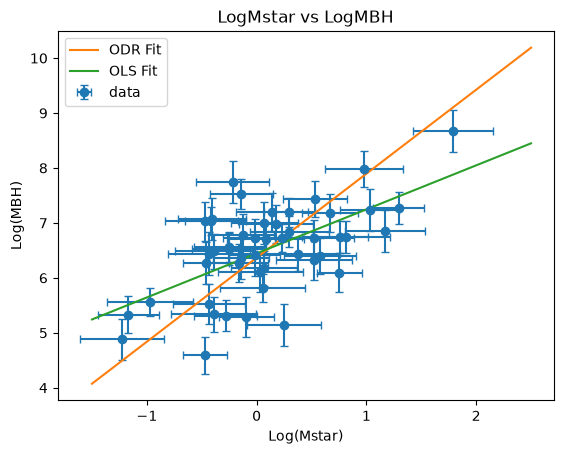

In [4]:
'''orthogonal distance regression'''
import scipy.odr as odr

def _line(B, x):
    return B[0] * (x - 9.5) + B[1]
    
_odr = odr.ODR(odr.RealData(lMs, lMBH, sx=lMs_err, sy=lMBH_err), odr.Model(_line), beta0=[w_alpha_hat, w_beta_hat])
odr_out = _odr.run()
alpha_odr, beta_odr = odr_out.beta
sig_alpha_odr = odr_out.sd_beta[0]
sig_beta_odr = odr_out.sd_beta[1]


plt.errorbar(lMs-9.5, lMBH, yerr=lMBH_err, xerr = lMs_err, fmt='o', capsize=3, label='data')
plt.plot(xx-9.5, beta_odr + alpha_odr*(xx-9.5),label = 'ODR Fit')
plt.plot(xx-9.5, beta_hat + alpha_hat*(xx-9.5), label = 'OLS Fit')

plt.title('LogMstar vs LogMBH');plt.xlabel('Log(Mstar)');plt.ylabel('Log(MBH)');plt.legend()


print(f"ODR Fitted Parameters:\nAlpha_hat = {alpha_odr:.2f} ± {sig_alpha_odr:.3f}\nBeta_hat = {beta_odr:.2f} ± {sig_beta_odr:.3f}")

#### Orthogonal distance regression

ODR assumes that that the scatter perpendicular to the fitted relation arises solely from the measured uncertainties. This assumption is not met because this data has some intrinsic scatter determined by nature. 

Generative Model Fitted Parameters:
Alpha_hat = 1.06 ± 0.222
Beta_hat = 6.42 ± 0.100
sig_int = 0.49 ± 0.093


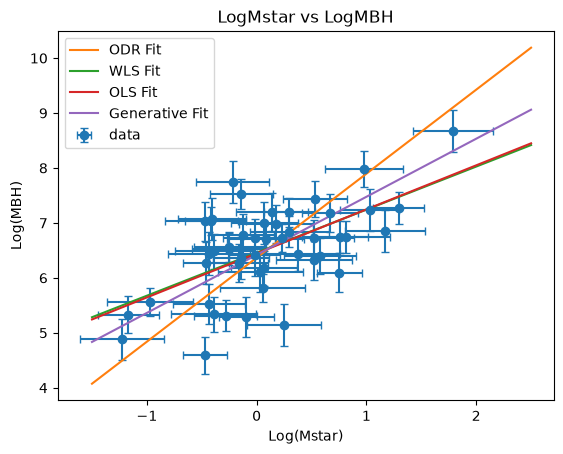

In [5]:
'''Generative model'''
from scipy.optimize import minimize

def neg2logL_gen(p, x, y, sx, sy):
    alpha, beta, log_sint, mu, log_sig_pop = p
    sint2, tau2 = np.exp(2 * log_sint), np.exp(2 * log_sig_pop)
    dx, dy = x - mu, y - (alpha * (mu - 9.5) + beta)
    s11 = tau2 + sx**2
    s22 = alpha**2 * tau2 + sint2 + sy**2
    s12 = alpha * tau2
    det = s11 * s22 - s12**2
    quad = (s22 * dx**2 - 2 * s12 * dx * dy + s11 * dy**2) / det
    return np.sum(np.log(det) + quad)

def hessian(func, theta, x,y,sx,sy, eps=1e-4):
    n = len(theta)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            di = np.zeros(n)
            dj = np.zeros(n)
            di[i] = eps
            dj[j] = eps

            H[i,j] = (func(theta + di + dj, x,y,sx,sy) - func(theta + di - dj, x,y,sx,sy) - func(theta - di + dj, x,y,sx,sy) + func(theta - di - dj, x,y,sx,sy))/(4*eps**2)
    return H


_start = [alpha_odr, beta_odr, np.log(0.3), lMs.mean(), np.log(lMs.std())]
res_gen = minimize(neg2logL_gen, _start, args=(lMs, lMBH, lMs_err, lMBH_err), method='Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000))
p_gen = res_gen.x
alpha_g,beta_g,glog_sint,gmu,glog_sig_pop = p_gen
cov_gen = 2 * np.linalg.inv(hessian(neg2logL_gen, p_gen,lMs,lMBH,lMs_err,lMBH_err))     # -2lnL curvature -> covariance
sint_gen = np.exp(p_gen[2])
sig_beta_g, sig_alpha_g, sig_sint_gen =  np.sqrt(cov_gen[1, 1]), np.sqrt(cov_gen[0, 0]), sint_gen * np.sqrt(cov_gen[2,2])




plt.errorbar(lMs-9.5, lMBH, yerr=lMBH_err, xerr = lMs_err, fmt='o', capsize=3, label='data')
plt.plot(xx-9.5, beta_odr + alpha_odr*(xx-9.5),label = 'ODR Fit')
plt.plot(xx-9.5, w_beta_hat + w_alpha_hat*(xx-9.5),label = 'WLS Fit')
plt.plot(xx-9.5, beta_hat + alpha_hat*(xx-9.5), label = 'OLS Fit')
plt.plot(xx-9.5, beta_g + alpha_g*(xx-9.5), label = 'Generative Fit')


plt.title('LogMstar vs LogMBH');plt.xlabel('Log(Mstar)');plt.ylabel('Log(MBH)');plt.legend()


print(f"Generative Model Fitted Parameters:\nAlpha_hat = {alpha_g:.2f} ± {sig_alpha_g:.3f}\nBeta_hat = {beta_g:.2f} ± {sig_beta_g:.3f}\nsig_int = {sint_gen:.2f} ± {sig_sint_gen:.3f}")

##### OLS & WLS

Both of these etimators do not take $\sigma_x$ into account when fitting the data. This causes a strong negative bias leading to a much shallower fit.

##### ODR

An effect of ODR divididing each residual by $\sqrt{\sigma_y^2 + \alpha^2\sigma_x^2}$ is that it is strongly biased towars high $\alpha$ values. This causes the fit to be much steeper than any other models. This data set also ignores $\sigma_{int}$ biasing the data even more.

##### Generative

This is the only model that takes into account both of the measured uncertainties but also the intrinsic scatter within the data. This model uses a more robust method to handel all of the different sources of error and should produce the least biased output.



**FINAL ANSWER:** $\alpha = $ _1.06_ $\pm$ _0.22_ unitless, $\beta = $ _6.42_ $\pm$ _0.10_ dex, $\sigma_{\rm int} = $ _0.49_ $\pm$ _0.09_ dex

**Justification and uncertainty method (a short paragraph):**

The final reported values are what is returned from the generative model with one sigma error bars. The generative model is the only one that takes the intrinsic, population and x scatter into account when fitting a line. This honest formulation leads me to be more confident that the values produced from this model will not be strongly biased in any way. The uncertainties come from the curvature of the log likelyhood plot which I can trust because this data meets the assuptions that the errors independent from one another. This curvature was calculated as a numerical hessian that can then be used to provide a covariance plot. 

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

1. I will create a dataset that has known parameters alpha, beta, log_sint, mu, and log_sig_pop. I will then run the generative model on this data to see if it's error bounds retain the true values. Failure for this check would be if my model is unable to produce bounds near or containing the true values for the fitted parameters.
2. I will write a simulation that will take my toy model and for n many iterations change the rng of the noise and estimate the mean $x_0$ values and its variance for each of my four estimators. This data will then be processed in a pandas dataframe where I can produce tables and a scatter plot showing how the variance and bias of each estimator. Failure would be if the scatter plot shows that my chosen generative model is highly biased when compared to the other models.
3. To check the coverage of each estimator I can use my dataframe to score each trial if the estimator included the true values. An estimator fails this check if the percent of trials that included the true parameters is less than 68%
4.  To check the sensitivity I will change the given x errors by 50% and feed that info into the generative model. Failure would be if the model does not return the true value of the toy data. I will then run another test where sig_int is 0 and check again to see if my model can handle these changes. I will also test the sensitivity of if the true popoulation is gaussian by drawing my xtrue values from a uniform distribution and seeing if I can recover the same values, failure here would be if the model returned vastly different parameters. 

In [6]:
# Part 3b: execute the plan here

'''Closure'''

# True values for toy model
Talpha = 1.4
Tbeta = 7.0
Tsint = 0.5
Tmu = 9.5
Tsig_pop = 0.6

# --------------------------------------------------
# Toy model generator
# --------------------------------------------------
def simulate_data(seed, N=len(lMs), alpha=Talpha, beta=Tbeta,
                  sint=Tsint, mu=Tmu, sig_pop=Tsig_pop):

    rng = np.random.default_rng(seed)

    # Draw true stellar masses from the population
    x_true = rng.normal(mu, sig_pop, N)

    # Relation plus intrinsic scatter gives true BH masses
    y_true = alpha*(x_true - 9.5) + beta + rng.normal(0, sint, N)

    # Use the measurement uncertainties from the real dataset
    inds = rng.integers(0, len(lMs_err), N)
    sx = lMs_err[inds]
    sy = lMBH_err[inds]

    # Corrupt both true quantities with measurement error
    x = x_true + rng.normal(0, sx)
    y = y_true + rng.normal(0, sy)

    return x, y, sx, sy


tx, ty, tsx, tsy = simulate_data(9282026)

# Estimate parameters
ttheta0 = [
    1.0,
    6.5,
    np.log(0.3),
    tx.mean(),
    np.log(tx.std())
]

tresult = minimize(
    neg2logL_gen,
    ttheta0,
    args=(tx, ty, tsx, tsy),
    method='Nelder-Mead',
    options=dict(xatol=1e-8, fatol=1e-8, maxiter=20000)
)

tp_gen = tresult.x

talpha, tbeta, tlog_sint, tmu, tlog_sig_pop = tp_gen

tsint = np.exp(tlog_sint)
tsig_pop = np.exp(tlog_sig_pop)

tH = hessian(
    neg2logL_gen,
    tp_gen,
    tx, ty, tsx, tsy
)

tcov = 2 * np.linalg.inv(tH)

talpha_sig = np.sqrt(tcov[0,0])
tbeta_sig = np.sqrt(tcov[1,1])

# Hessian gives uncertainty in log(sigma_int),
# so transform it to uncertainty in sigma_int
tsint_sig = tsint * np.sqrt(tcov[2,2])

print(
    f"Generative closure:\n"
    f"Alpha = {talpha:.2f} ± {talpha_sig:.2f} "
    f"(true = {Talpha})\n"
    f"Beta = {tbeta:.2f} ± {tbeta_sig:.2f} "
    f"(true = {Tbeta})\n"
    f"Sigma_int = {tsint:.2f} ± {tsint_sig:.2f} "
    f"(true = {Tsint})\n"
    f"Mu = {tmu:.2f} "
    f"(true = {Tmu})\n"
    f"Sigma_pop = {tsig_pop:.2f} "
    f"(true = {Tsig_pop})"
)

Generative closure:
Alpha = 1.29 ± 0.15 (true = 1.4)
Beta = 7.17 ± 0.10 (true = 7.0)
Sigma_int = 0.47 ± 0.10 (true = 0.5)
Mu = 9.40 (true = 9.5)
Sigma_pop = 0.76 (true = 0.6)


#### Closure

When testing on toy data my model was able to return bounds that included all of the fitted parameters in either 1$\sigma$ or very close. Beta being slightly off could correspond that my error bounds being set at 1$\sigma$ means I will only retain the true values 68% of the time, while a 1.7$\sigma$ error is significant the matching of the other values makes me confident in my model. Still containing every other parameter gives me confidence in the fit above. 

In [7]:
'''Bias and Efficiency'''

from scipy import odr
import pandas as pd

def ols_est(x, y, sx, sy):
    X = np.column_stack((x - 9.5, np.ones(len(x))))
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    alpha, beta = theta
    return alpha


def wls_est(x, y, sx, sy):
    X = np.column_stack((x - 9.5, np.ones(len(x))))
    W = np.diag(1 / sy**2)

    theta = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y
    alpha, beta = theta
    return alpha


def odr_est(x, y, sx, sy):

    def linear(B, x):
        return B[0]*(x - 9.5) + B[1]

    model = odr.Model(linear)
    data = odr.RealData(x, y, sx=sx, sy=sy)

    fit = odr.ODR(data, model,beta0=[1.0, 6.5]).run()

    return fit.beta[0]


def gen_est(x, y, sx, sy):

    theta0 = [1.0, 6.5, np.log(0.3), x.mean(),np.log(x.std()) ]

    result = minimize(neg2logL_gen, theta0,args=(x, y, sx, sy), method='Nelder-Mead',options=dict(xatol=1e-8,fatol=1e-8,maxiter=20000))

    return result.x[0]

def estimate_all(x, y, sx, sy):
    return {"OLS" : ols_est(x, y, sx, sy),"WLS" : wls_est(x, y, sx, sy),"ODR" : odr_est(x, y, sx, sy),"Generative" : gen_est(x, y, sx, sy)}

n_mc = 1000
results = []

for seed in range(n_mc):

    x, y, sx, sy = simulate_data(seed)

    row = estimate_all(x, y, sx, sy)

    row["seed"] = seed

    results.append(row)

df = pd.DataFrame(results)

L = ['OLS', 'WLS', 'ODR', 'Generative']

data = []

for i in L:

    bia = np.mean(df[i]) - Talpha
    var = np.var(df[i])

    d = {'Estimator': i,'bias': bia,'variance': var}
    data.append(d)

fdf = pd.DataFrame(data)

fdf


,Estimator,bias,variance
0,OLS,-0.309559,0.026640
1,WLS,-0.310515,0.027749
2,ODR,0.347596,0.076801
3,Generative,0.033485,0.058768


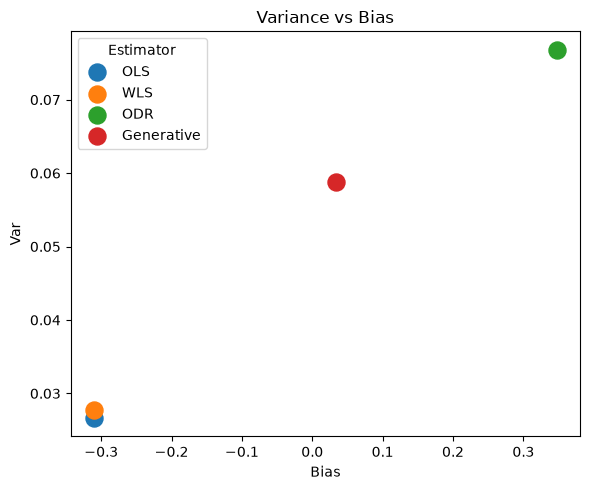

In [8]:
plt.figure(figsize=(6,5))

for _, row in fdf.iterrows():

    plt.scatter(
        row["bias"],
        row["variance"],
        s=150,
        label=row["Estimator"]
    )

plt.xlabel("Bias")
plt.ylabel(r"$\mathrm{Var}$")
plt.title('Variance vs Bias')

plt.legend(title="Estimator")
plt.tight_layout()

#### Bias and efficientcy

In this scatter plot we can see clearly how OLS and WLS have a strong negative bias from ignoring $\sigma_x$. ODR gains a positive bias by having the slope in the denominator when it divides its residuals and ignoring the intrinsic scatter. Finally the generative has near 0 bias because it accounts for all types of error. OLS and WLS have the smallest variance because they make stronger assumptions about the data and ignore most of the sources of variance within the data itself. The generative model retains its position as my prefered model

In [9]:
'''Coverage'''

coverage = {}
for est in ['OLS', 'WLS', 'ODR', 'Generative']:

    covered = np.abs(df[est] - Talpha) < np.std(df[est])

    coverage[est] = covered.mean()

print(pd.Series(coverage))

OLS           0.175
WLS           0.181
ODR           0.441
Generative    0.729
dtype: float64


In [10]:
alpha_covered = []
beta_covered = []
sint_covered = []

def gen_fit(x,y,sx,sy):
    theta0 = [alpha_g,beta_g,np.log(0.3),x.mean(),np.log(x.std())]
    result = minimize(neg2logL_gen,theta0,args=(x,y,sx,sy),method='Nelder-Mead',options=dict(xatol=1e-8,fatol=1e-8,maxiter=20000))
    p = result.x
    alpha,beta,log_sint,mu,log_sig_pop = p
    sint = np.exp(log_sint)
    sig_alpha,sig_beta,sig_sint = np.nan,np.nan,np.nan
    curvature_ok = False

    try:
        H = hessian(neg2logL_gen,p,x,y,sx,sy)
        eigvals = np.linalg.eigvalsh(H)
        if np.all(eigvals > 0) and np.linalg.cond(H) < 1e12:
            cov = 2*np.linalg.inv(H)
            sig_alpha = np.sqrt(cov[0,0])
            sig_beta = np.sqrt(cov[1,1])
            sig_sint = sint*np.sqrt(cov[2,2])
            curvature_ok = True
    except np.linalg.LinAlgError:
        pass

    return {'alpha':alpha,'alpha_err':sig_alpha,'beta':beta,'beta_err':sig_beta,'sint':sint,'sint_err':sig_sint,'success':result.success,'curvature_ok':curvature_ok}


for seed in range(n_mc):

    x,y,sx,sy = simulate_data(seed)

    fit = gen_fit(x,y,sx,sy)

    if fit['success'] and fit['curvature_ok']:

        alpha_covered.append(abs(fit['alpha']-Talpha) <= fit['alpha_err'])
        beta_covered.append(abs(fit['beta']-Tbeta) <= fit['beta_err'])
        sint_covered.append(abs(fit['sint']-Tsint) <= fit['sint_err'])

print(f"Alpha coverage = {np.mean(alpha_covered):.3f}")
print(f"Beta coverage = {np.mean(beta_covered):.3f}")
print(f"Sigma_int coverage = {np.mean(sint_covered):.3f}")

Alpha coverage = 0.663
Beta coverage = 0.637
Sigma_int coverage = 0.680


#### Coverage

For all three fitted values that we care about from the generative model the truth was contained in ~ 68% of the time, this is consistent with me choosing 1 sigma error bars. The model passes this test.

In [11]:
'''Sensitivity'''

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# --------------------------------------------------
# Change only this seed for all sensitivity tests
# --------------------------------------------------
sens_seed = 9282026

# --------------------------------------------------
# Baseline and +/- 50% x-error tests
# --------------------------------------------------
tx,ty,tsx,tsy = simulate_data(sens_seed)

fit_correct = gen_fit(tx,ty,tsx,tsy)
fit_low = gen_fit(tx,ty,0.5*tsx,tsy)
fit_high = gen_fit(tx,ty,1.5*tsx,tsy)


# --------------------------------------------------
# Uniform true-x population
# Same mean and variance as Gaussian population
# --------------------------------------------------
def simulate_uniform(seed,N=len(lMs),alpha=Talpha,beta=Tbeta,sint=Tsint,mu=Tmu,sig_pop=Tsig_pop):
    rng = np.random.default_rng(seed)
    half_width = np.sqrt(3)*sig_pop
    x_true = rng.uniform(mu-half_width,mu+half_width,N)
    y_true = alpha*(x_true-9.5)+beta+rng.normal(0,sint,N)
    inds = rng.integers(0,len(lMs_err),N)
    sx,sy = lMs_err[inds],lMBH_err[inds]
    x = x_true+rng.normal(0,sx)
    y = y_true+rng.normal(0,sy)
    return x,y,sx,sy

tx_u,ty_u,tsx_u,tsy_u = simulate_uniform(sens_seed)
fit_uniform = gen_fit(tx_u,ty_u,tsx_u,tsy_u)


# --------------------------------------------------
# True intrinsic scatter = 0
# --------------------------------------------------
tx_0,ty_0,tsx_0,tsy_0 = simulate_data(sens_seed,sint=0.0)
fit_zero = gen_fit(tx_0,ty_0,tsx_0,tsy_0)


# --------------------------------------------------
# Compact results
# --------------------------------------------------
def pm(value,error):
    if np.isfinite(error):
        return f"{value:.3f} +/- {error:.3f}"
    return f"{value:.3f} (err unavailable)"

sensitivity_results = pd.DataFrame({
    'Test':['Baseline','sx -50%','sx +50%','Uniform x','sigma_int = 0'],
    'Alpha':[pm(fit_correct['alpha'],fit_correct['alpha_err']),pm(fit_low['alpha'],fit_low['alpha_err']),pm(fit_high['alpha'],fit_high['alpha_err']),pm(fit_uniform['alpha'],fit_uniform['alpha_err']),pm(fit_zero['alpha'],fit_zero['alpha_err'])],
    'Beta':[pm(fit_correct['beta'],fit_correct['beta_err']),pm(fit_low['beta'],fit_low['beta_err']),pm(fit_high['beta'],fit_high['beta_err']),pm(fit_uniform['beta'],fit_uniform['beta_err']),pm(fit_zero['beta'],fit_zero['beta_err'])],
    'Sigma_int':[pm(fit_correct['sint'],fit_correct['sint_err']),pm(fit_low['sint'],fit_low['sint_err']),pm(fit_high['sint'],fit_high['sint_err']),pm(fit_uniform['sint'],fit_uniform['sint_err']),pm(fit_zero['sint'],fit_zero['sint_err'])],
    'Converged':[fit_correct['success'],fit_low['success'],fit_high['success'],fit_uniform['success'],fit_zero['success']]
})

print(f"True alpha = {Talpha:.3f}, beta = {Tbeta:.3f}, sigma_int = {Tsint:.3f}")
print("For the final row, true sigma_int = 0.\n")
print(sensitivity_results.to_string(index=False))

True alpha = 1.400, beta = 7.000, sigma_int = 0.500
For the final row, true sigma_int = 0.

         Test                   Alpha                    Beta               Sigma_int  Converged
     Baseline         1.291 +/- 0.147         7.166 +/- 0.102         0.470 +/- 0.104       True
      sx -50%         1.142 +/- 0.126         7.147 +/- 0.100         0.576 +/- 0.083       True
      sx +50%         1.578 +/- 0.221         7.200 +/- 0.119         0.140 +/- 0.416       True
    Uniform x         1.260 +/- 0.206         7.145 +/- 0.104         0.503 +/- 0.107       True
sigma_int = 0 1.288 (err unavailable) 7.085 (err unavailable) 0.000 (err unavailable)       True


##### Sensitivity

The model proved to be very sensitive to most changes to the data. Even when sx +50% retuned a very small sigma_int the error values scalled p so that the truth was still included. This output proves that my model is rebust to changes in the underlying ditribution, intrinsic errors and measurment errors in the x direction. 

**WHAT THE CHECKS FOUND:**

The checks found that my choosen generative model works in most situatoins with muy data. The most concerning results was th $1.7\sigma$ discrapancy in estimating $\beta$ when using toy data combined with the result that my model only returned bounds that contained the true Beta 63.7% of the time instead of 68% of the time as expected. Individually I wouldn't mind these results but combined it tells me that my model is slightly less efficient when calculating the y intercept of the line. 

This appeared to be the only checks failed by my model and it proved to work succesfully when testnig its sensitivity to changes. 

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

I used copilot to explain the generative model and check my code to ensure that I was recreating the analysis correctly. I also had it explain what assumptions ODR makes about the data and used that information in my analysis

For the varification plan, since it followed the same structure as lab2, I used old code and if there was substantial editing to be done I used copilot to update my old code with the new variables and functions. By having it keep my style of coding the output was formatted in a way that I could follow and independently verify to make sure that my verification was still correct.


As always, all of the writing is my own and AI contributed solely ideas and menial tasks.